# Imports

In [3]:
import pandas as pd

In [41]:
import matplotlib.pyplot as plt


In [71]:
import seaborn as sns 

# Load Data

In [9]:
events=pd.read_csv(r"C:\Users\arjun\OneDrive\Documents\MY PROJECTS\Player Behavior Analysis Project\events.csv")
users=pd.read_csv(r"C:\Users\arjun\OneDrive\Documents\MY PROJECTS\Player Behavior Analysis Project\users.csv")

# Preview Data

In [14]:
events.head()

,user_id,event_date,event_type
0,1,2024-01-07 00:00:00,session_start
1,1,2024-01-08 00:00:00,session_start
2,1,2024-01-09 00:00:00,session_start
3,1,2024-01-10 00:00:00,session_start
4,1,2024-01-11 00:00:00,session_start


In [15]:
users.head()

,user_id,install_date
0,1,07/01/2024
1,2,20/01/2024
2,3,29/01/2024
3,4,15/01/2024
4,5,11/01/2024


In [16]:
events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27291 entries, 0 to 27290
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     27291 non-null  int64 
 1   event_date  27291 non-null  object
 2   event_type  27291 non-null  object
dtypes: int64(1), object(2)
memory usage: 639.8+ KB


In [17]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   user_id       5000 non-null   int64 
 1   install_date  5000 non-null   object
dtypes: int64(1), object(1)
memory usage: 78.3+ KB


In [23]:
events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27291 entries, 0 to 27290
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     27291 non-null  int64         
 1   event_date  27291 non-null  datetime64[ns]
 2   event_type  27291 non-null  object        
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 639.8+ KB


In [24]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   user_id       5000 non-null   int64         
 1   install_date  5000 non-null   datetime64[ns]
dtypes: datetime64[ns](1), int64(1)
memory usage: 78.3 KB


In [26]:
users_events.head()

,user_id,event_date,event_type,install_date
0,1,2024-01-07,session_start,2024-01-07
1,1,2024-01-08,session_start,2024-01-07
2,1,2024-01-09,session_start,2024-01-07
3,1,2024-01-10,session_start,2024-01-07
4,1,2024-01-11,session_start,2024-01-07


# Data Preprocessing (Cleaning, Date Conversion and Merging)

In [27]:
users.isnull().sum()

user_id         0
install_date    0
dtype: int64

In [28]:
events.isnull().sum()

user_id       0
event_date    0
event_type    0
dtype: int64

In [21]:
events['event_date']=pd.to_datetime(events['event_date'],format="%Y-%m-%d %H:%M:%S")

In [22]:
users['install_date']=pd.to_datetime(users['install_date'],format="%d/%m/%Y")

In [25]:
users_events=events.merge(users,on='user_id',how='left')

# Data Analysis

# DAU,WAU,MAU 

In [47]:
Daily_Access_Users=users_events.groupby('event_date')['user_id'].nunique().reset_index()
Daily_Access_Users.columns = ['date', 'dau']
Daily_Access_Users

,date,dau
0,2024-01-01,169
1,2024-01-02,313
2,2024-01-03,439
3,2024-01-04,529
4,2024-01-05,603
...,...,...
60,2024-03-01,2
61,2024-03-02,2
62,2024-03-03,1
63,2024-03-04,1


In [35]:
users_events['week'] = users_events['event_date'].dt.to_period('W').apply(lambda r: r.start_time)

In [36]:
wau = users_events.groupby('week')['user_id'].nunique().reset_index()
wau.columns = ['week', 'wau']
wau


,week,wau
0,2024-01-01,1177
1,2024-01-08,1661
2,2024-01-15,1838
3,2024-01-22,1944
4,2024-01-29,1118
5,2024-02-05,278
6,2024-02-12,71
7,2024-02-19,13
8,2024-02-26,2
9,2024-03-04,1


In [38]:
users_events['month'] = users_events['event_date'].dt.to_period('M').astype(str)


In [39]:
mau = users_events.groupby('month')['user_id'].nunique().reset_index()
mau.columns = ['month', 'mau']
mau


,month,mau
0,2024-01,5000
1,2024-02,624
2,2024-03,2


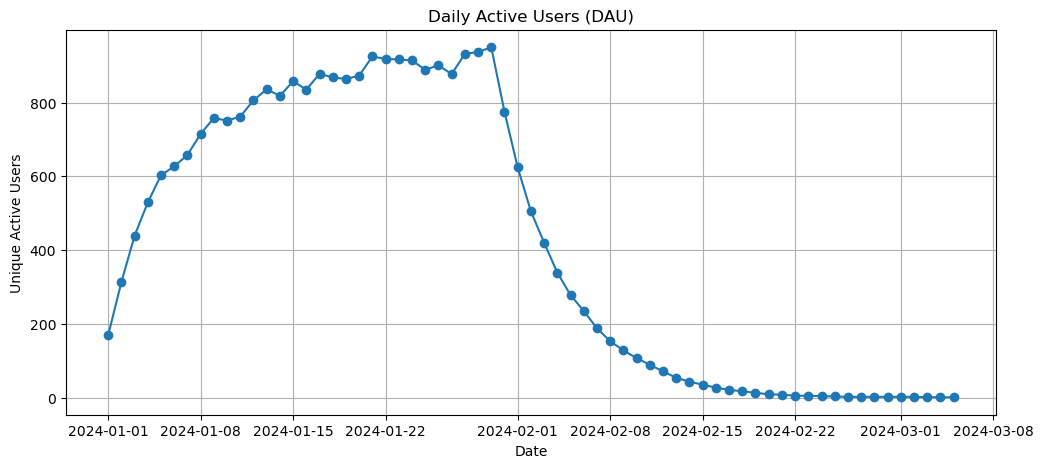

In [75]:
plt.figure(figsize=(12,5))
plt.plot(Daily_Access_Users['date'], Daily_Access_Users['dau'], marker='o')
plt.title('Daily Active Users (DAU)')
plt.xlabel('Date')
plt.ylabel('Unique Active Users')
plt.grid(True)
plt.savefig("plots/dau.png")
plt.show()


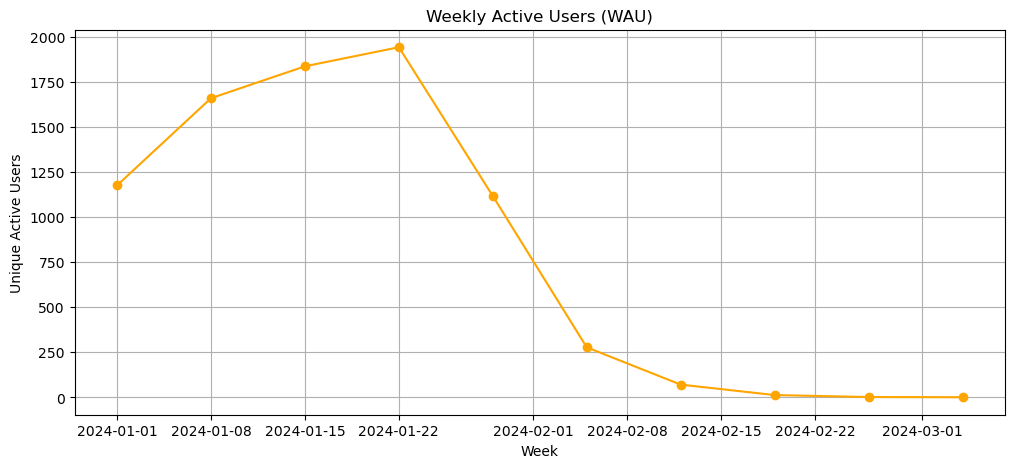

In [76]:
plt.figure(figsize=(12,5))
plt.plot(wau['week'], wau['wau'], marker='o', color='orange')
plt.title('Weekly Active Users (WAU)')
plt.xlabel('Week')
plt.ylabel('Unique Active Users')
plt.grid(True)
plt.savefig("plots/wau.png")
plt.show()


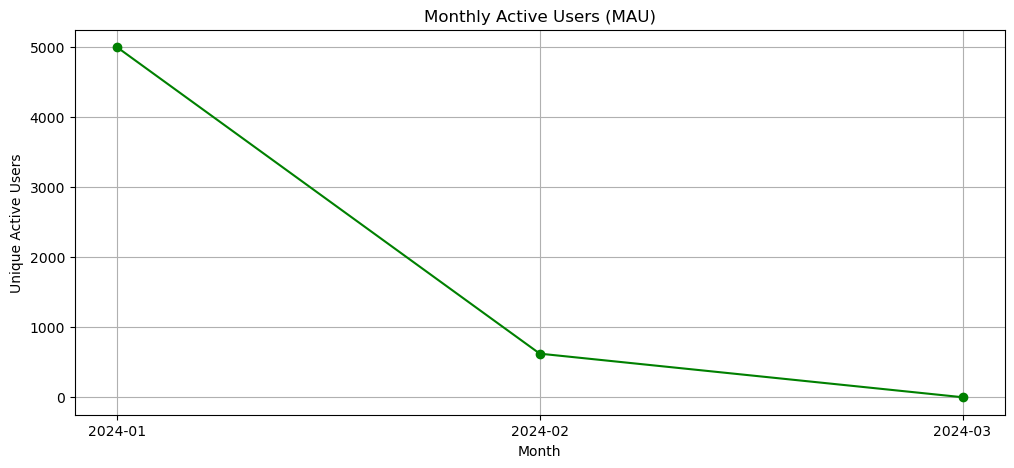

In [77]:
plt.figure(figsize=(12,5))
plt.plot(mau['month'], mau['mau'], marker='o', color='green')
plt.title('Monthly Active Users (MAU)')
plt.xlabel('Month')
plt.ylabel('Unique Active Users')
plt.grid(True)
plt.savefig("plots/mau.png")
plt.show()


# Retention Analysis (D1, D7, D30)

In [54]:
users_events['days_since_install'] = (
    users_events['event_date'] - users_events['install_date']
).dt.days


In [55]:
d1_users = users_events[users_events['days_since_install'] == 1]['user_id'].nunique()
d7_users = users_events[users_events['days_since_install'] == 7]['user_id'].nunique()
d30_users = users_events[users_events['days_since_install'] == 30]['user_id'].nunique()


In [56]:
total_installs = users['user_id'].nunique()

d1_rate = d1_users / total_installs
d7_rate = d7_users / total_installs
d30_rate = d30_users / total_installs


In [57]:
retention = pd.DataFrame({
    'metric': ['D1 Retention', 'D7 Retention', 'D30 Retention'],
    'rate': [d1_rate, d7_rate, d30_rate]
})

retention


,metric,rate
0,D1 Retention,0.8188
1,D7 Retention,0.2422
2,D30 Retention,0.0024


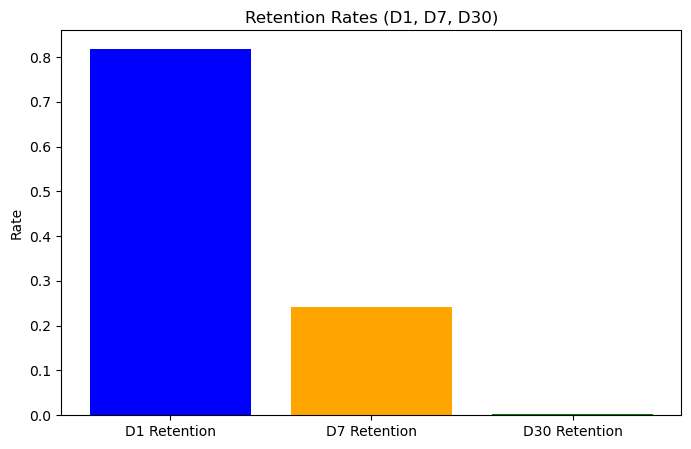

In [78]:
plt.figure(figsize=(8,5))
plt.bar(retention['metric'], retention['rate'], color=['blue','orange','green'])
plt.title('Retention Rates (D1, D7, D30)')
plt.ylabel('Rate')
plt.savefig("plots/retention_rates.png")
plt.show()


# Churn Analysis

In [59]:
users_events['days_since_install'] = (
    users_events['event_date'] - users_events['install_date']
).dt.days


In [60]:
d1_users = users_events[users_events['days_since_install'] == 1]['user_id'].nunique()
d7_users = users_events[users_events['days_since_install'] == 7]['user_id'].nunique()
d30_users = users_events[users_events['days_since_install'] == 30]['user_id'].nunique()


In [61]:
total_installs = users_events['user_id'].nunique()


In [62]:
d1_rate = d1_users / total_installs
d7_rate = d7_users / total_installs
d30_rate = d30_users / total_installs


In [63]:
d1_churn = 1 - d1_rate
d7_churn = 1 - d7_rate
d30_churn = 1 - d30_rate


In [64]:
churn = pd.DataFrame({
    'metric': ['D1 Churn', 'D7 Churn', 'D30 Churn'],
    'rate': [d1_churn, d7_churn, d30_churn]
})

churn


,metric,rate
0,D1 Churn,0.1812
1,D7 Churn,0.7578
2,D30 Churn,0.9976


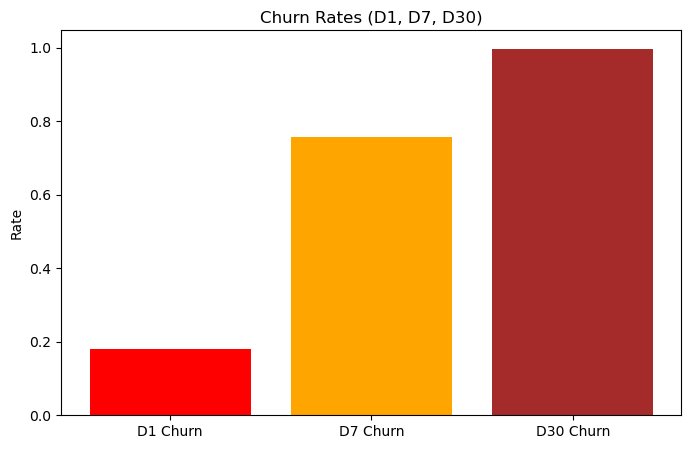

In [79]:
plt.figure(figsize=(8,5))
plt.bar(churn['metric'], churn['rate'], color=['red','orange','brown'])
plt.title('Churn Rates (D1, D7, D30)')
plt.ylabel('Rate')
plt.savefig("plots/Churn_rates.png")
plt.show()


# Cohort Analysis 

In [66]:
users_events['install_month'] = users_events['install_date'].dt.to_period('M').astype(str)


In [67]:
users_events['days_since_install'] = (
    users_events['event_date'] - users_events['install_date']
).dt.days


In [68]:
cohort = users_events.groupby(
    ['install_month', 'days_since_install']
)['user_id'].nunique().reset_index()

cohort


,install_month,days_since_install,user_id
0,2024-01,0,5000
1,2024-01,1,4094
2,2024-01,2,3331
3,2024-01,3,2696
4,2024-01,4,2203
5,2024-01,5,1794
6,2024-01,6,1458
7,2024-01,7,1211
8,2024-01,8,1008
9,2024-01,9,811


In [69]:
cohort_matrix = cohort.pivot(
    index='install_month',
    columns='days_since_install',
    values='user_id'
)

cohort_matrix


days_since_install,0,1,2,3,4,5,6,7,8,9,...,29,30,31,32,33,34,35,36,37,38
install_month,,,,,,,,,,,,,,,,,,,,,
2024-01,5000,4094,3331,2696,2203,1794,1458,1211,1008,811,...,16,12,8,8,7,6,4,3,2,1


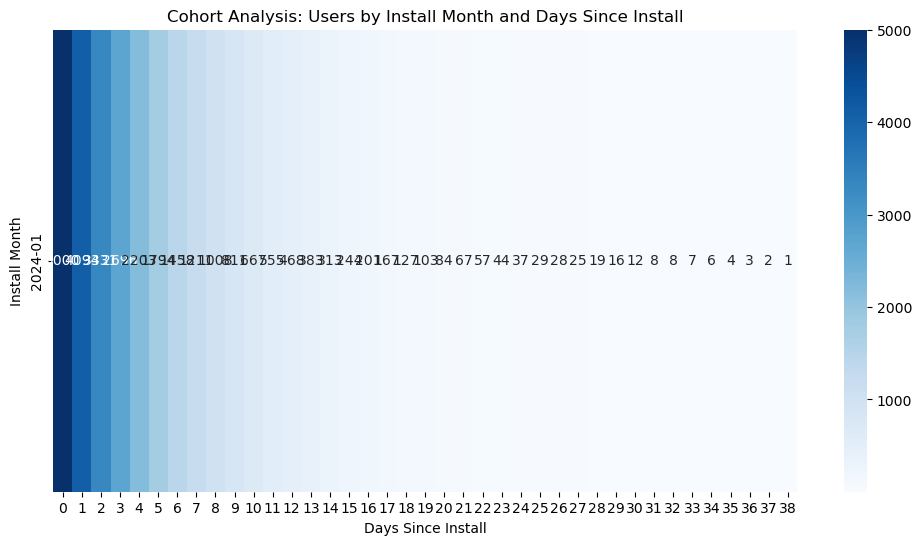

In [80]:
plt.figure(figsize=(12,6))
sns.heatmap(cohort_matrix, annot=True, fmt='.0f', cmap='Blues')
plt.title('Cohort Analysis: Users by Install Month and Days Since Install')
plt.xlabel('Days Since Install')
plt.ylabel('Install Month')
plt.savefig("plots/cohort_heatmap.png")
plt.show()
